# Sales Forecasting (ARIMA & SARIMA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error
import itertools
import warnings
warnings.filterwarnings("ignore")

## Load Data

In [2]:
df = pd.read_csv(r'C:\Users\dhruv joshi\Downloads\mobile_sales_data.csv')
df.columns = df.columns.str.strip()
df.head()

,Product,Brand,Product Code,Product Specification,Price,Inward Date,Dispatch Date,Quantity Sold,Customer Name,Customer Location,Region,Core Specification,Processor Specification,RAM,ROM,SSD
0,Mobile Phone,Motorola,88EB4558,Site candidate activity company there bit insi...,78570,2023-08-02,2023-08-03,6,William Hess,South Kelsey,Central,NaN,Snapdragon 7 Gen,12GB,128GB,NaN
1,Laptop,Oppo,416DFEEB,Beat put care fight affect address his.,44613,2023-10-03,2023-10-06,1,Larry Smith,North Lisa,South,Ryzen 5,Ryzen 5,8GB,512GB,256GB
2,Mobile Phone,Samsung,9F975B08,Energy special low seven place audience.,159826,2025-03-19,2025-03-20,5,Leah Copeland,South Todd,Central,NaN,MediaTek Dimensity,8GB,256GB,NaN
3,Laptop,Sony,73D2A7CC,Friend record hard contain minute we role sea ...,20911,2024-02-06,2024-03-27,1,Dan Kirby,New Jordanmouth,South,i7,i7,12GB,64GB,2TB
4,Laptop,Microsoft,CCE0B80D,Program recently feeling save tree hotel people.,69832,2023-08-10,2023-09-10,4,Dean Martin,Keithton,East,i7,i7,8GB,128GB,2TB


## Preprocessing

In [3]:
df['Dispatch Date'] = pd.to_datetime(df['Dispatch Date'])
df['Revenue'] = df['Price'] * df['Quantity Sold']
ts = df.groupby('Dispatch Date')['Revenue'].sum()
ts = ts.asfreq('D').fillna(0)
ts = ts.resample('M').sum()
ts.head()

Dispatch Date
2023-03-31      40741997
2023-04-30     511016938
2023-05-31    1055285898
2023-06-30    1110777770
2023-07-31    1145411923
Freq: ME, Name: Revenue, dtype: int64

## Visualization

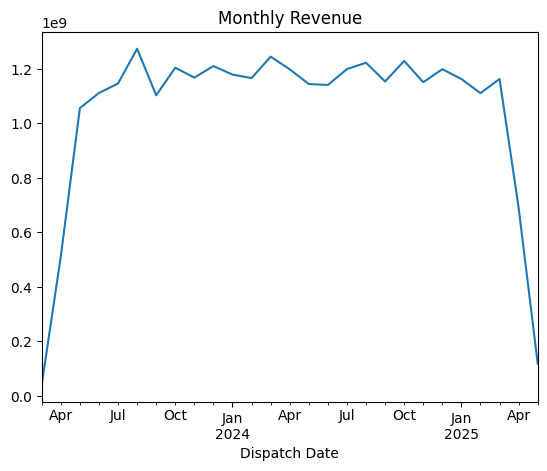

In [4]:
plt.figure()
ts.plot()
plt.title('Monthly Revenue')
plt.show()

## Stationarity Test

In [5]:
result = adfuller(ts)
print('ADF p-value:', result[1])

ADF p-value: 1.0


## Train Test Split

In [6]:
train = ts[:int(len(ts)*0.8)]
test = ts[int(len(ts)*0.8):]

## ARIMA Tuning

In [7]:
p=d=q=range(0,3)
pdq=list(itertools.product(p,d,q))
best_aic=float('inf')
best_order=None
for order in pdq:
    try:
        model=ARIMA(train,order=order).fit()
        if model.aic<best_aic:
            best_aic=model.aic
            best_order=order
    except:
        continue
print('Best order:',best_order)

Best order: (1, 2, 0)


## ARIMA Model

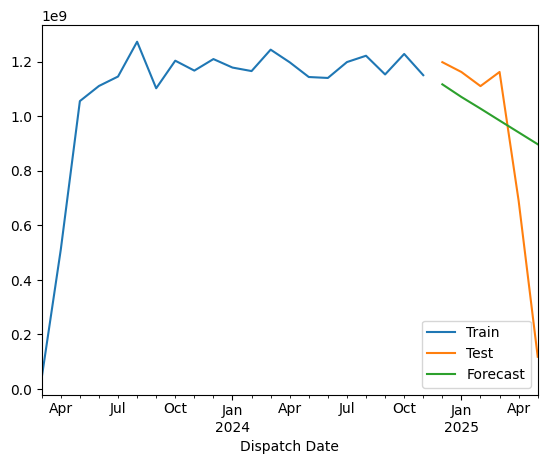

RMSE: 347388045.62442523


In [8]:
model=ARIMA(train,order=best_order).fit()
pred=model.forecast(len(test))
plt.figure()
train.plot(label='Train')
test.plot(label='Test')
pred.plot(label='Forecast')
plt.legend()
plt.show()
print('RMSE:',np.sqrt(mean_squared_error(test,pred)))

## SARIMA Model

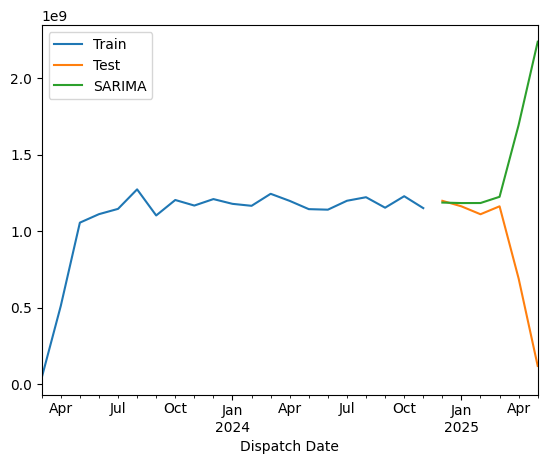

SARIMA RMSE: 959181052.8054557


In [9]:
sarima=SARIMAX(train,order=(1,1,1),seasonal_order=(1,1,1,12)).fit()
spred=sarima.forecast(len(test))
plt.figure()
train.plot(label='Train')
test.plot(label='Test')
spred.plot(label='SARIMA')
plt.legend()
plt.show()
print('SARIMA RMSE:',np.sqrt(mean_squared_error(test,spred)))